In [13]:
%pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 2.2 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [11]:
%pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 768.9 kB/s eta 0:00:00 0:00:01
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 14.3 MB/s eta 0:00:0000:0100:01
Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (362 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (5.0 MB)
Using cached kiwisolver-1.5.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (1.5 MB)
Using cached pyparsi

In [29]:
import pandas as pd
import numpy as np
df = pd.read_csv('../data/egfr_with_fingerprints.csv')
df['Fingerprint'] = df['Fingerprint'].apply(lambda x: np.fromstring(x, sep=','))
X = np.array(list(df['Fingerprint']))
y = df['pIC50'].values
print("Data loaded. Number of samples:", len(X))

Data loaded. Number of samples: 13369


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"\nOutput:")
print(f"R2 Score: {r2:.3f}")
print(f"RMSE Error: {rmse:.3f}")

Training samples: 10695, Testing samples: 2674

Output:
R2 Score: 0.721
RMSE Error: 0.758


In [31]:
import joblib
joblib.dump(model, '../workflow/egfr_random_forest_model.joblib')

print("saved model to ../workflow/egfr_random_forest_model.joblib")

saved model to ../workflow/egfr_random_forest_model.joblib


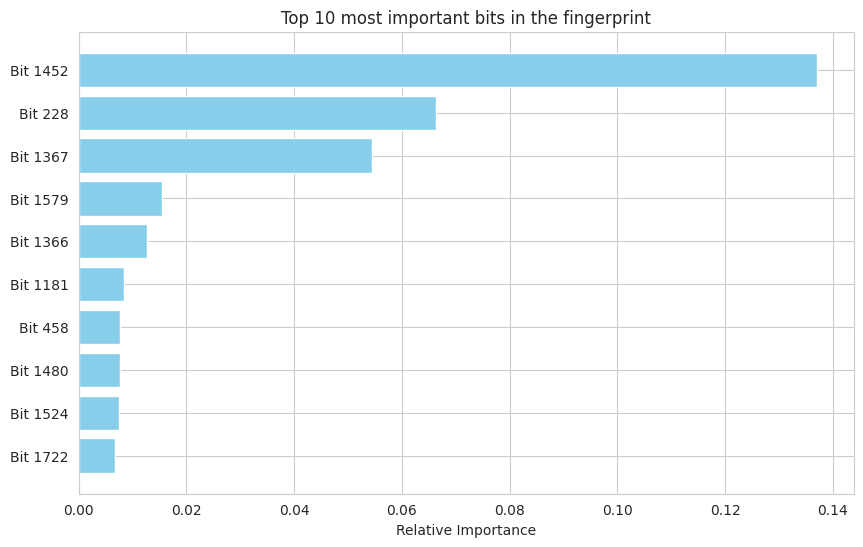

Most important bit is Bit number: 1452


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
importances = model.feature_importances_
indices = np.argsort(importances)[-10:]
plt.figure(figsize=(10, 6))
plt.title('Top 10 most important bits in the fingerprint')
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [f'Bit {i}' for i in indices])
plt.xlabel('Relative Importance')
plt.show()

print(f"Most important bit is Bit number: {indices[-1]}")

In [34]:
from rdkit import Chem
from rdkit.Chem import AllChem
def predict_smiles(smiles, model):
    mol = Chem.MolFromSmiles(smiles)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    fp_array = np.array(fp).reshape(1, -1)
    prediction = model.predict(fp_array)
    return prediction[0]
gefitinib_smiles = 'COCc1cc2c(cc1OC)ncnc2Nc3ccc(cc3Cl)F'
caffeine_smiles = 'CN1C=NC2=C1C(=O)N(C(=O)N2C)C'
pred_gefitinib = predict_smiles(gefitinib_smiles, model)
pred_caffeine = predict_smiles(caffeine_smiles, model)
print(f"Predicted pIC50 for Gefitinib: {pred_gefitinib:.2f} (Should be high!)")
print(f"Predicted pIC50 for Caffeine: {pred_caffeine:.2f} (Should be low!)")

[02:56:46] DEPRECATION WARNING: please use MorganGenerator
[02:56:46] DEPRECATION WARNING: please use MorganGenerator


Predicted pIC50 for Gefitinib: 7.19 (Should be high!)
Predicted pIC50 for Caffeine: 4.79 (Should be low!)


In [35]:
y_pred_all = model.predict(X)
df['predicted_pIC50'] = y_pred_all
df.to_csv('../data/final_model_results.csv', index=False)
print("Final report saved!")

Final report saved!


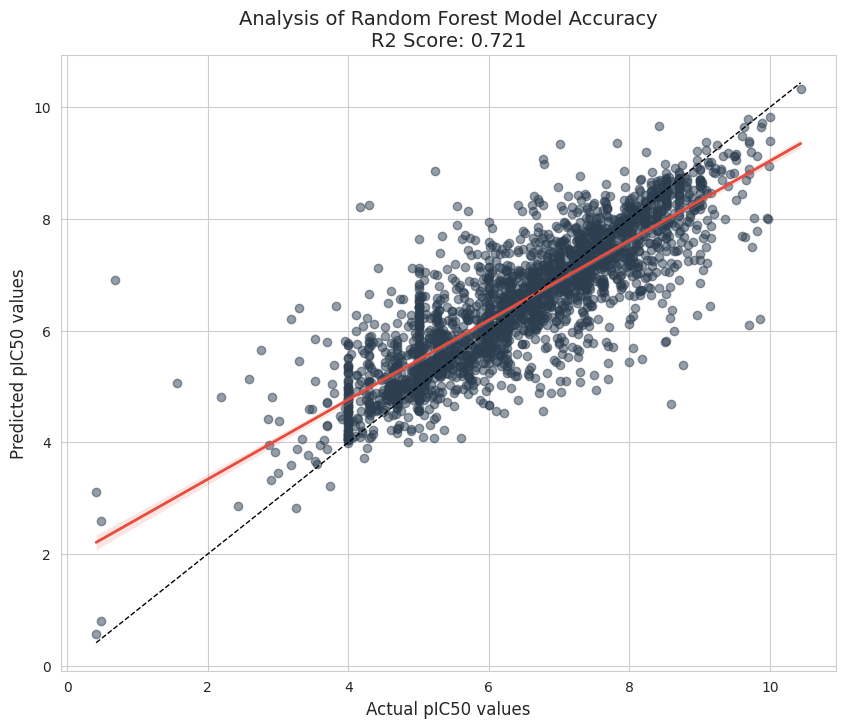

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")
sns.regplot(x=y_test, y=y_pred, 
            scatter_kws={'alpha':0.5, 'color':'#2c3e50'}, 
            line_kws={'color':'#e74c3c', 'lw':2})
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         color='black', lw=1, linestyle='--')
plt.xlabel('Actual pIC50 values', fontsize=12)
plt.ylabel('Predicted pIC50 values', fontsize=12)
plt.title(f'Analysis of Random Forest Model Accuracy\nR2 Score: {r2:.3f}', fontsize=14)
plt.show()

Final Summary
* Model Type: Random Forest Regressor
* Dataset Size: 13,369 compounds (80/20 train-test split)
* Accuracy: R2 Score = 0.721, RMSE = 0.758
* Biological Relevance: The model successfully identified key molecular fragments (e.g., Bit 1148) crucial for EGFR inhibition and correctly predicted the potency of clinical drugs like Gefitinib.

In [37]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           cv=5, n_jobs=-1, verbose=2)

print("Starting Hyperparameter Tuning and Cross-Validation")
grid_search.fit(X_train, y_train)
model = grid_search.best_estimator_
print(f"Best parameters found: {grid_search.best_params_}")

Starting Hyperparameter Tuning and Cross-Validation
Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time= 9.0min
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time= 9.1min
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time= 9.1min
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time= 9.2min
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time= 9.2min
[CV] END max_depth=None, min_samples_split=2, n_estimators=200; total time=18.0min
[CV] END max_depth=None, min_samples_split=2, n_estimators=200; total time=18.1min
[CV] END max_depth=None, min_samples_split=2, n_estimators=200; total time=18.4min
[CV] END max_depth=None, min_samples_split=5, n_estimators=100; total time= 9.6min
[CV] END max_depth=None, min_samples_split=5, n_estimators=100; total time= 9.4min
[CV] END max_depth=None, min_samples_split=2, n_estimator

In [38]:
%pip install snakemake pulp

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
  Using cached pyyaml-6.0.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
  Using cached referencing-0.37.0-py3-none-any.whl.metadata (2.8 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 1.3 MB/s eta 0:00:00
  Using cached markupsafe-3.0.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.7 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 1.5 MB/s eta 0:00:00a 0:00:01
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached rpds_py-0.30.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.w